## Kendall's tau

Both `pv.Bicop` instances expose a `.tau` property; for the parametric Clayton it returns the analytic value $\theta / (\theta + 2)$, for `pv.tll` it returns a sample-based estimate from the fitted density.  `PFNRBicop.tau()` mirrors `pyvinecopulib`'s `KernelBicop::parameters_to_tau`: draw `n` quasi-random points via `pv.ghalton(n, 2)`, apply the inverse Rosenblatt transform along the first axis (using the inner regressor's `icdf`), then compute the weighted Kendall's $\tau$ on the resulting copula sample via `pv.wdm`.

## Setup

`PFNRBicop` wraps the local `tabpfn` package, which authenticates once via the `TABPFN_TOKEN` environment variable and then runs locally; no further cloud calls happen at inference time.  We pull the token from `.env` via `python-dotenv` (a dev-group dependency).

On CPU, TabPFN refuses to fit on more than 1000 samples by default.  Pass `model_kwargs={"ignore_pretraining_limits": True}` to `PFNRBicop` (or set the `TABPFN_ALLOW_CPU_LARGE_DATASET=1` environment variable) if you have a GPU and want to use a bigger sample.

In [2]:
from dotenv import load_dotenv

load_dotenv()  # populates TABPFN_TOKEN from .env

import matplotlib.pyplot as plt
import numpy as np
import pyvinecopulib as pv

from npcc import PFNRBicop

c:\Users\flbuc\OneDrive\Documents\Research\npcc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulate from a Clayton copula and fit `PFNRBicop`

We pick $\theta = 3$ (strong positive lower-tail dependence), draw $n = 1000$ pseudo-observations (the CPU default cap), and fit `PFNRBicop` with its defaults (`symmetric=True`, `method="criterion"`).  The fit downloads the TabPFN-v3 regressor checkpoint on first call and caches it in the platform cache directory.

In [3]:
rho = 3.0
clayton = pv.Bicop(
  family=pv.BicopFamily.clayton,
  parameters=np.asarray([[rho]], dtype=np.float64),
)
u_train = clayton.simulate(n=1000, seeds=[2, 2, 4])

pfnr = PFNRBicop()
pfnr.fit(u_train[:, 0], u_train[:, 1])

In [13]:
import torch
import numpy as np

# Small sample for inspection
v_test = u_train[:5, 1]  # First 5 samples of V
# The inner model for u_given_vx was trained on features [v, constant_x]
# In the unconditional case, x is a column of ones
x_test = np.ones((len(v_test), 1))
features_test = np.column_stack([v_test, x_test])

# Convert to torch tensor (n, 2) for TabPFN
features_torch = torch.as_tensor(features_test, dtype=torch.float64)

# Use the wrapper's _predict_full method
logits, criterion = pfnr.u_given_vx_._predict_full(features_torch)

print("=== FULL OUTPUT INSPECTION ===\n")
print("Logits (returned from _predict_full):")
print(f"  Type: {type(logits)}")
print(f"  Shape: {logits.shape}")
print(f"  Dtype: {logits.dtype}")
print(f"  Device: {logits.device}")
print(
  f"  Sample values (first row):\n{logits[0, :10]}  (showing first 10 of {logits.shape[1]})\n"
)

print("Criterion (returned from _predict_full):")
print(f"  Type: {type(criterion)}")
attrs = [m for m in dir(criterion) if not m.startswith("_")]
print(f"  Public methods/attributes: {len(attrs)} total")
print(f"  Sample: {attrs[:15]}")
print()

# Inspect criterion structure
if hasattr(criterion, "borders"):
  print(f"  borders shape: {criterion.borders.shape}")
if hasattr(criterion, "bucket_widths"):
  print(f"  bucket_widths shape: {criterion.bucket_widths.shape}")

# Test PDF evaluation
# logits shape is (n_samples, n_bins), so for 1 sample: (1, 5000)
# y must have shape matching logits[:-1], so (1,) for a scalar per sample
z_first = torch.tensor(
  [0.5], dtype=torch.float32, device=logits.device
)  # Single evaluation point
print(f"\nTesting criterion.pdf() with single z value:")
print(f"  logits[0:1] shape: {logits[0:1].shape}")
print(f"  z_first shape: {z_first.shape}")

pdf_val = criterion.pdf(logits[0:1], z_first)
print(f"  PDF result shape: {pdf_val.shape}")
print(f"  PDF at z=0.5: {pdf_val.item():.6e}")

# For multiple z values, we need to replicate logits
z_test = torch.tensor(
  [-1.0, -0.5, 0.0, 0.5, 1.0], dtype=torch.float32, device=logits.device
)
logits_expanded = logits[0:1].expand(len(z_test), -1)  # Repeat for each z
print(f"\nTesting with multiple z values:")
print(f"  logits_expanded shape: {logits_expanded.shape}")
print(f"  z_test shape: {z_test.shape}")

pdf_vals = criterion.pdf(logits_expanded, z_test)
print(f"  PDF result shape: {pdf_vals.shape}")
print(
  f"  PDF values at z={z_test.cpu().numpy()}: {pdf_vals.detach().cpu().numpy()}"
)

=== FULL OUTPUT INSPECTION ===

Logits (returned from _predict_full):
  Type: <class 'torch.Tensor'>
  Shape: torch.Size([5, 5000])
  Dtype: torch.float32
  Device: cuda:0
  Sample values (first row):
tensor([-15.0207, -16.2941, -17.0316, -17.5929, -17.7381, -17.8802, -18.0080,
        -18.3736, -18.4968, -18.3612], device='cuda:0')  (showing first 10 of 5000)

Criterion (returned from _predict_full):
  Type: <class 'tabpfn.architectures.base.bar_distribution.FullSupportBarDistribution'>
  Public methods/attributes: 85 total
  Sample: ['T_destination', 'add_module', 'apply', 'assert_support', 'average_bar_distributions_into_this', 'bfloat16', 'borders', 'bucket_widths', 'buffers', 'call_super_init', 'cdf', 'cdf_temporary', 'children', 'compile', 'compute_scaled_log_probs']

  borders shape: torch.Size([5001])
  bucket_widths shape: torch.Size([5000])

Testing criterion.pdf() with single z value:
  logits[0:1] shape: torch.Size([1, 5000])
  z_first shape: torch.Size([1])
  PDF result sh

In [15]:
# Single (u, v) pair: analyze empty bins in one direction
u_single = 0.3
v_single = 0.7

print(f"=== ANALYZING U | V, X FOR (u={u_single}, v={v_single}) ===\n")

# Direction: Predict U | V, X (using u_given_vx_)
features_u = np.array([[v_single, 1.0]], dtype=np.float64)  # [v, constant_x=1]
features_u_torch = torch.as_tensor(features_u, dtype=torch.float64)
logits_u, criterion_u = pfnr.u_given_vx_._predict_full(features_u_torch)

logits_single = logits_u[0]  # shape: (5000,)

# Count empty bins (logits == -inf)
num_bins_total = logits_single.shape[0]
is_empty = torch.isinf(logits_single) & (logits_single < 0)
num_empty = is_empty.sum().item()
num_nonempty = num_bins_total - num_empty

print(f"Input features: [v={v_single}, x=1.0]")
print(f"Total bins: {num_bins_total}")
print(
  f"Empty bins (logits = -∞): {num_empty} ({100 * num_empty / num_bins_total:.1f}%)"
)
print(
  f"Non-empty bins: {num_nonempty} ({100 * num_nonempty / num_bins_total:.1f}%)\n"
)

# Find contiguous runs of empty bins at the edges
logits_np = logits_single.detach().cpu().numpy()
is_empty_np = np.isinf(logits_np) & (logits_np < 0)

# Count empty bins at the start
empty_at_start = 0
for i in range(len(is_empty_np)):
  if is_empty_np[i]:
    empty_at_start += 1
  else:
    break

# Count empty bins at the end
empty_at_end = 0
for i in range(len(is_empty_np) - 1, -1, -1):
  if is_empty_np[i]:
    empty_at_end += 1
  else:
    break

print(f"Empty bins at start: {empty_at_start}")
print(f"Empty bins at end: {empty_at_end}")
print(f"First non-empty bin index: {empty_at_start}")
print(f"Last non-empty bin index: {num_bins_total - empty_at_end - 1}\n")

# Show logits around the boundaries
print(f"Logits near start (indices 0-9):")
print(f"  {logits_np[:10]}\n")

print(f"Logits near end (indices {num_bins_total - 10}-{num_bins_total - 1}):")
print(f"  {logits_np[-10:]}\n")

# Show statistics for non-empty bins
logits_nonempty = logits_np[~is_empty_np]
print(f"Non-empty bin logits statistics:")
print(f"  Min: {logits_nonempty.min():.4f}")
print(f"  Max: {logits_nonempty.max():.4f}")
print(f"  Mean: {logits_nonempty.mean():.4f}")
print(f"  Median: {np.median(logits_nonempty):.4f}")

=== ANALYZING U | V, X FOR (u=0.3, v=0.7) ===

Input features: [v=0.7, x=1.0]
Total bins: 5000
Empty bins (logits = -∞): 2 (0.0%)
Non-empty bins: 4998 (100.0%)

Empty bins at start: 0
Empty bins at end: 0
First non-empty bin index: 0
Last non-empty bin index: 4999

Logits near start (indices 0-9):
  [-15.139375 -16.360977 -17.015663 -17.617773 -17.776491 -17.85486
 -18.021496 -18.414286 -18.554453 -18.409214]

Logits near end (indices 4990-4999):
  [-15.104056  -15.104056  -15.001402  -14.977304  -15.218467  -14.864826
 -14.8231535 -14.452294  -14.226337  -13.658728 ]

Non-empty bin logits statistics:
  Min: -20.3862
  Max: -6.0274
  Mean: -14.1203
  Median: -15.6239


In [17]:
# Calculate density per bin from logits
print("\n=== DENSITY PER BIN FROM LOGITS ===\n")

# Extract the logits and criterion details
logits_np = logits_np.astype(np.float64)  # Use higher precision
borders = criterion_u.borders.detach().cpu().numpy()
bucket_widths = criterion_u.bucket_widths.detach().cpu().numpy()

print(f"Borders shape: {borders.shape} (defines {len(bucket_widths)} bins)")
print(f"Bucket widths shape: {bucket_widths.shape}")
print(
  f"Bin widths min/max: {bucket_widths.min():.6f} / {bucket_widths.max():.6f}\n"
)

# Identify zero-width bins
zero_width_bins = np.where(bucket_widths == 0.0)[0]
print(f"Zero-width bins: {len(zero_width_bins)}")
if len(zero_width_bins) > 0:
  print(
    f"  Indices: {zero_width_bins[:20]}{'...' if len(zero_width_bins) > 20 else ''}\n"
  )

# Step 1: Softmax over logits to get probability mass in each bin
# p_k = exp(logits_k) / sum_j(exp(logits_j))
# Use log-sum-exp trick for numerical stability
log_Z = np.logaddexp.reduce(logits_np)  # log(sum_j(exp(logits_j)))
log_probs = logits_np - log_Z  # log(p_k)
probs = np.exp(log_probs)  # p_k - probability mass in each bin

print("Probability mass in bins:")
print(f"  Sum of probabilities (should be ~1.0): {probs.sum():.10f}")
print(f"  Min/max: {probs.min():.6e} / {probs.max():.6e}\n")

# Step 2: Divide by bin width to get density (exclude zero-width bins)
# density_k = p_k / width_k
densities = np.full_like(probs, np.nan)
valid_bins = bucket_widths > 0
densities[valid_bins] = probs[valid_bins] / bucket_widths[valid_bins]

print("Density per bin (valid bins only):")
print(f"  Valid bins: {valid_bins.sum()} / {len(bucket_widths)}")
print(f"  Min: {np.nanmin(densities):.6e}")
print(f"  Max: {np.nanmax(densities):.6e}")
print(f"  Mean: {np.nanmean(densities):.6e}\n")

# Show bin densities for the widest and narrowest valid bins
widest_idx = np.argmax(bucket_widths)
narrowest_valid = np.min(bucket_widths[bucket_widths > 0])
narrowest_idx = np.where(bucket_widths == narrowest_valid)[0][0]

print(f"Widest bin (index {widest_idx}):")
print(f"  Width: {bucket_widths[widest_idx]:.6f}")
print(f"  Probability mass: {probs[widest_idx]:.6e}")
print(f"  Density: {densities[widest_idx]:.6e}\n")

print(f"Narrowest valid bin (index {narrowest_idx}):")
print(f"  Width: {bucket_widths[narrowest_idx]:.6f}")
print(f"  Probability mass: {probs[narrowest_idx]:.6e}")
print(f"  Density: {densities[narrowest_idx]:.6e}\n")

# Verify: integrating density × width should give total probability 1
integral_check = np.nansum(densities[valid_bins] * bucket_widths[valid_bins])
print(f"Integration check (∫ density × dwidth): {integral_check:.10f}")

# Show the top 10 densest bins
valid_densities = densities.copy()
valid_densities[~valid_bins] = -np.inf
top_10_indices = np.argsort(valid_densities)[-10:][::-1]
print(f"\nTop 10 densest bins:")
for rank, idx in enumerate(top_10_indices, 1):
  print(
    f"  {rank:2d}. Bin {idx:4d}: density={densities[idx]:.6e}, mass={probs[idx]:.6e}, width={bucket_widths[idx]:.6f}"
  )


=== DENSITY PER BIN FROM LOGITS ===

Borders shape: (5001,) (defines 5000 bins)
Bucket widths shape: (5000,)
Bin widths min/max: 0.000000 / 195.435898

Zero-width bins: 1
  Indices: [2329]

Probability mass in bins:
  Sum of probabilities (should be ~1.0): 1.0000000000
  Min/max: 0.000000e+00 / 2.411857e-03

Density per bin (valid bins only):
  Valid bins: 4999 / 5000
  Min: 0.000000e+00
  Max: 4.109714e-01
  Mean: 3.769486e-02

Widest bin (index 4999):
  Width: 195.435898
  Probability mass: 1.169741e-06
  Density: 5.985294e-09

Narrowest valid bin (index 2328):
  Width: 0.000185
  Probability mass: 7.108666e-06
  Density: 3.844733e-02

Integration check (∫ density × dwidth): 1.0000000000

Top 10 densest bins:
   1. Bin 2579: density=4.109714e-01, mass=2.411857e-03, width=0.005869
   2. Bin 2578: density=4.084990e-01, mass=2.293903e-03, width=0.005615
   3. Bin 2576: density=4.074000e-01, mass=2.237356e-03, width=0.005492
   4. Bin 2577: density=4.062448e-01, mass=2.206786e-03, width

## Quantitative comparison on a regular grid

We evaluate the fitted density on a $30 \times 30$ uniform grid, alongside the true Clayton density and `pv.tll` (a transformed local-likelihood benchmark) on the same grid.  Three error metrics:
$$
\mathrm{ISE} = \mathbb{E}\bigl[(\hat c - c)^2\bigr], \quad
\mathrm{IAE} = \mathbb{E}\bigl[|\hat c - c|\bigr], \quad
\mathrm{KL}  = \mathbb{E}\!\left[c (\log c - \log \hat c)\right].
$$
The `PFNRBicop` adapter from `as_bicop()` exposes the same `pdf(uv)` interface as a `pv.Bicop`, so the three estimators evaluate uniformly.  When the queried `uv` happens to span a Cartesian grid the adapter automatically reroutes through the fast `pdf_grid` path.

In [6]:
M = 30
u_axis = np.linspace(1 / M, 1 - 1 / M, M)
v_axis = np.linspace(1 / M, 1 - 1 / M, M)
U_mesh, V_mesh = np.meshgrid(u_axis, v_axis)
grid_uv = np.column_stack([U_mesh.flatten(), V_mesh.flatten()])

tll = pv.Bicop.from_data(u_train, pv.FitControlsBicop(family_set=[pv.tll]))

c_true = clayton.pdf(grid_uv)
c_tll = tll.pdf(grid_uv)
c_pfnr = pfnr.as_bicop().pdf(grid_uv)


def grid_metrics(
  c_true: np.ndarray, c_hat: np.ndarray, eps: float = 1e-12
) -> dict[str, float]:
  c_hat = np.maximum(c_hat, eps)
  c_true = np.maximum(c_true, eps)
  return {
    "ISE": float(np.mean((c_hat - c_true) ** 2)),
    "IAE": float(np.mean(np.abs(c_hat - c_true))),
    "KL": float(np.mean(c_true * (np.log(c_true) - np.log(c_hat)))),
  }


print("TLL  :", grid_metrics(c_true, c_tll))
print("PFNR :", grid_metrics(c_true, c_pfnr))

TLL  : {'ISE': 0.13400762953344256, 'IAE': 0.10812078964429203, 'KL': 0.017855115118899697}
PFNR : {'ISE': 0.1172351858298041, 'IAE': 0.14433569894090983, 'KL': 0.04304712880676252}


## Contour plots on standard-normal margins

All three estimators expose a `plot()` method that hands off to `pyvinecopulib`'s plotting helper.  For `PFNRBicop`, this goes through `as_bicop()` — the duck-typed adapter that exposes `var_types = ["c", "c"]` and `pdf(uv)`, exactly what `pyvinecopulib`'s plotter expects.  The Cartesian-grid fast path applies automatically.

Each call produces its own figure inline below.

True (Clayton, theta = 3.0)


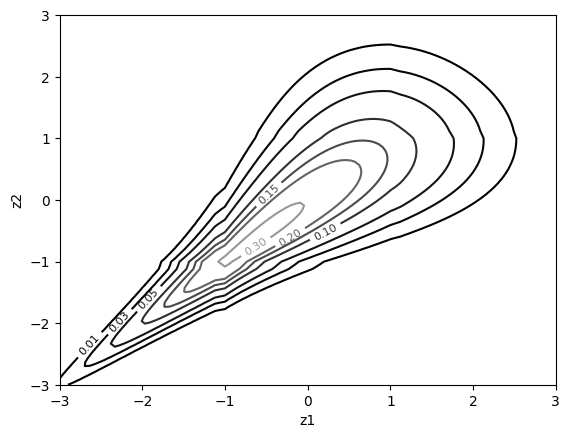

In [7]:
print("True (Clayton, theta = %.1f)" % rho)
clayton.plot(type="contour", margin_type="norm")

TLL benchmark


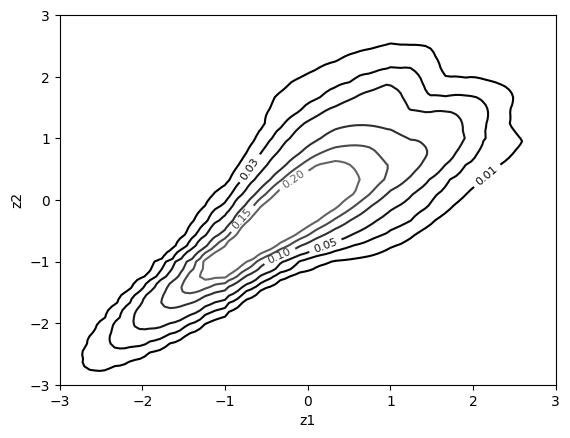

In [8]:
print("TLL benchmark")
tll.plot(type="contour", margin_type="norm")

PFNRBicop (criterion method, symmetric)


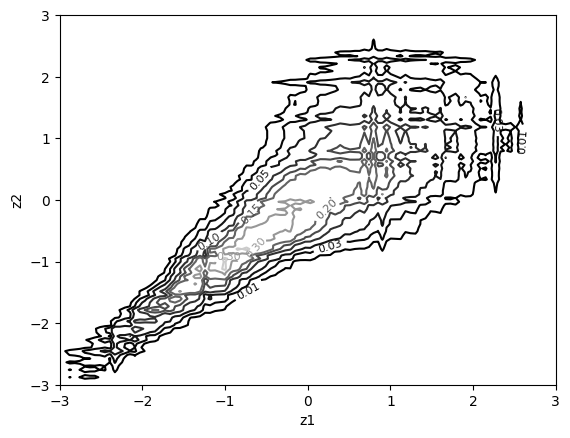

In [9]:
print("PFNRBicop (criterion method, symmetric)")
pfnr.plot(plot_type="contour", margin_type="norm")

## Kendall's tau

Both `pv.Bicop` instances expose a `.tau` property; for the parametric Clayton it returns the analytic value $\theta / (\theta + 2)$, for `pv.tll` it returns a sample-based estimate from the fitted density.  `PFNRBicop.tau()` mirrors `pyvinecopulib`'s `KernelBicop::parameters_to_tau`: draw `n` quasi-random points via `pv.ghalton(n, 2)`, apply the inverse Rosenblatt transform along the first axis (using the inner regressor's `icdf`), then compute the weighted Kendall's $\tau$ on the resulting copula sample via `pv.wdm`.

In [10]:
tau_pfnr = pfnr.tau(n=1000)

print(f"Clayton tau (analytic) : {clayton.tau:.4f}")
print(f"TLL tau                : {tll.tau:.4f}")
print(f"PFNRBicop tau (qmc)    : {tau_pfnr:.4f}")

Clayton tau (analytic) : 0.6000
TLL tau                : 0.5871
PFNRBicop tau (qmc)    : 0.6172


## h-function errors on the grid

h-functions are conditional CDFs — $h_1(u, v) = F_{U \mid V}(u \mid v) = \partial C / \partial v$, $h_2(u, v) = F_{V \mid U}(v \mid u) = \partial C / \partial u$.  They take values in $[0, 1]$, so we compare them via integrated squared and absolute errors only:
$$
\mathrm{ISE}_h = \mathbb{E}\bigl[(\hat h - h)^2\bigr], \quad
\mathrm{IAE}_h = \mathbb{E}\bigl[|\hat h - h|\bigr].
$$
`pv.Bicop.hfunc1` / `hfunc2` provide the truth and the `tll` benchmark; `PFNRBicop.hfunc1` / `hfunc2` are the direct conditional CDFs from the inner regressors (one batched call each, no integration).

In [11]:
h1_true = clayton.hfunc1(grid_uv)
h2_true = clayton.hfunc2(grid_uv)
h1_tll = tll.hfunc1(grid_uv)
h2_tll = tll.hfunc2(grid_uv)
h1_pfnr = pfnr.hfunc1(grid_uv[:, 0], grid_uv[:, 1])
h2_pfnr = pfnr.hfunc2(grid_uv[:, 0], grid_uv[:, 1])


def grid_h_metrics(h_true: np.ndarray, h_hat: np.ndarray) -> dict[str, float]:
  return {
    "ISE": float(np.mean((h_hat - h_true) ** 2)),
    "IAE": float(np.mean(np.abs(h_hat - h_true))),
  }


print("hfunc1 (TLL ) :", grid_h_metrics(h1_true, h1_tll))
print("hfunc1 (PFNR) :", grid_h_metrics(h1_true, h1_pfnr))
print("hfunc2 (TLL ) :", grid_h_metrics(h2_true, h2_tll))
print("hfunc2 (PFNR) :", grid_h_metrics(h2_true, h2_pfnr))

hfunc1 (TLL ) : {'ISE': 0.00032067363335572783, 'IAE': 0.011994421563663104}
hfunc1 (PFNR) : {'ISE': 0.00030555563847330417, 'IAE': 0.011838591750666379}
hfunc2 (TLL ) : {'ISE': 0.00024406018756566633, 'IAE': 0.011090978853956497}
hfunc2 (PFNR) : {'ISE': 0.00023747011409029604, 'IAE': 0.00952461012732413}


## Joint CDF heatmap

The joint CDF on the $30 \times 30$ Cartesian grid is computed in a single batched call via `pfnr.cdf_grid(u_axis, v_axis)`.  Compare the visual shape against the true Clayton CDF.

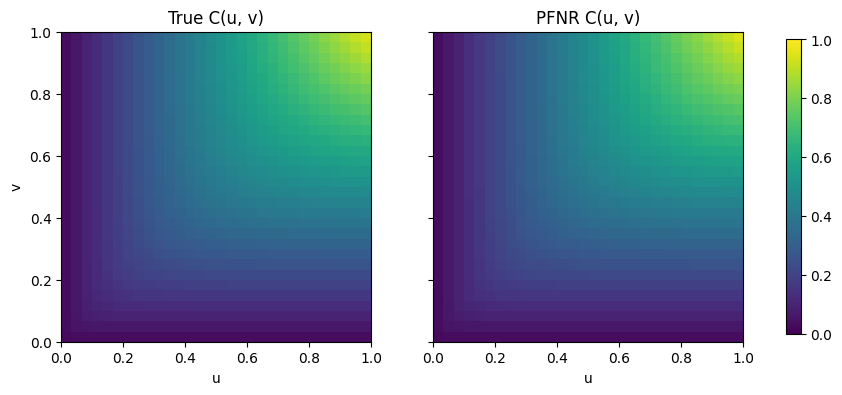

In [12]:
C_true = clayton.cdf(grid_uv).reshape(M, M)
C_pfnr = pfnr.cdf_grid(
  u_axis, v_axis, n_int=64
).T  # transpose to align with meshgrid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, data, title in [
  (axes[0], C_true, "True C(u, v)"),
  (axes[1], C_pfnr, "PFNR C(u, v)"),
]:
  im = ax.imshow(
    data,
    origin="lower",
    extent=(0.0, 1.0, 0.0, 1.0),
    aspect="equal",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
  )
  ax.set_title(title)
  ax.set_xlabel("u")
axes[0].set_ylabel("v")
fig.colorbar(im, ax=axes, shrink=0.85)
plt.show()